In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

CSV_PATH = "golf_shot_data_reversed.csv"

df = pd.read_csv(CSV_PATH)



In [29]:
df.shape[0]

33

In [27]:
df['キャリー (yds)'].max()

106

In [26]:
df['最高到達点 (yds)'].max()

22

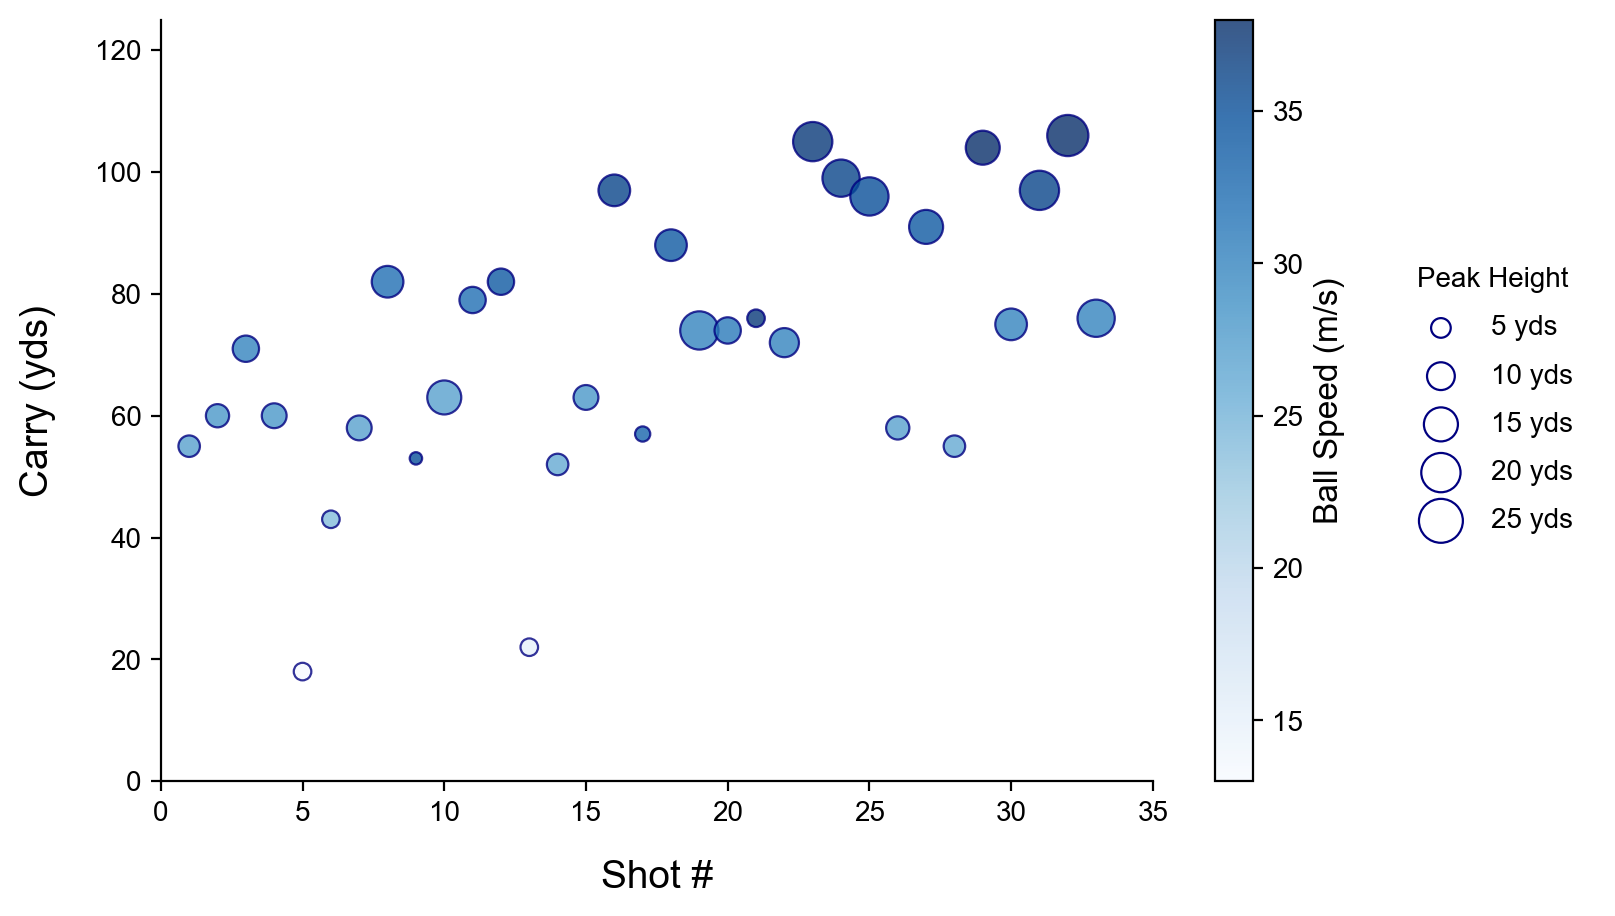

In [31]:
plt.figure(figsize=(8, 8 / 1.618), dpi=200)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = ['Arial']

# 散布図作成
scatter = plt.scatter(
    df['No.'],
    df['キャリー (yds)'],
    c=df['ボールスピード (m/s)'],
    s=df['最高到達点 (yds)'] * 10,
    cmap='Blues',
    alpha=0.8,
    edgecolors='navy',
    linewidths=0.8
)

plt.xlabel('Shot #', labelpad=12, fontsize=14)
plt.ylabel('Carry (yds)', labelpad=14, fontsize=14)
plt.xlim(0, 35)
plt.ylim(0, 125)

# ボールスピードを示すカラーバー
cbar = plt.colorbar(scatter)
cbar.set_label('Ball Speed (m/s)', fontsize=12)

# 円の大きさ（最高到達点）を示す凡例の作成
height_samples = [5, 10, 15, 20, 25]
legend_handles = []
for h in height_samples:
    handle = plt.scatter(
        [], [],
        c='none',
        s=h * 10,
        edgecolors='navy',
        linewidths=0.8,
        label=f'{h} yds'
    )
    legend_handles.append(handle)

plt.legend(
    handles=legend_handles,
    title='Peak Height',
    loc='center left',
    bbox_to_anchor=(1.24, 0.5),
    frameon=False,
    labelspacing=0.8,
    borderpad=0.8,
    borderaxespad=0.0
)

# 画像の保存と表示
plt.savefig('carry_speed_height_scatter_with_legend.png', bbox_inches='tight', dpi=200)
plt.show()
